In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import mpld3
import os
import webbrowser
import matplotlib
import mplcursors

# data_01_socio_economic_102_v20240607 (Население)

In [2]:
df = pd.read_excel('data_01_socio_economic_102_v20240607.xlsx')

In [3]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Население,Y4170101000000,Численность населения,CD,Российская Федерация,страна,0,0,2000,146303.6,"оценка на конец года, тысяч человек",Данные за 2011‒2021 гг. пересчитаны с учетом и...,Регионы России. Социально-экономические показа...


In [4]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [5]:
df = df[df['indicator_name'] != "Смертность населения (без показателя смертности от внешних причин)"]

In [6]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    assert(all([df1['year'].value_counts().values[i] == len(df1['object_name'].unique()) for i in range(len(df1['year'].value_counts().values))]))
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [7]:
df = pd.concat(dfs, axis=0)

In [8]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [9]:
# инициализируем года
Население = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

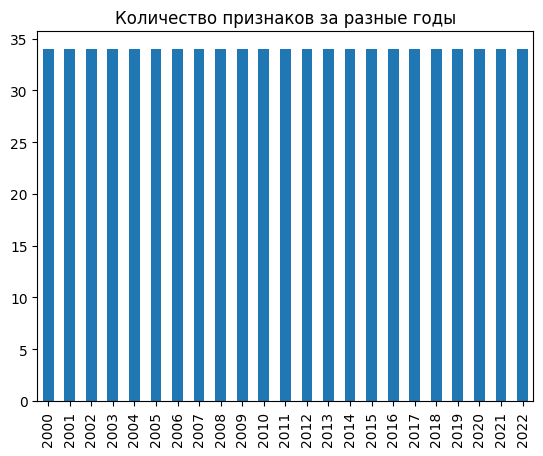

In [10]:
for key in Население.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Население[key] = new_df

total = set()
for key in Население.keys():
    total.update(set(Население[key].columns))

for key in Население.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Население[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Население[year].columns) - 3 for year in Население.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_02_socio_economic_102_v20240607 (Труд)

In [13]:
df = pd.read_excel('data_02_socio_economic_102_v20240607.xlsx')

In [14]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Труд,Y4170201000000,Численность рабочей силы,CD,Российская Федерация,страна,0,0,2000,72770.0,по данным выборочных обследований рабочей силы...,До 2017 г. обследование проводилось в отношени...,Регионы России. Социально-экономические показа...


In [15]:
needed_cols = np.array([k for k, v in df['indicator_name'].value_counts().items() if v == 2208])

In [16]:
df = df[df['indicator_name'].isin(needed_cols)]

In [17]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [18]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    assert(all([df1['year'].value_counts().values[i] == len(df1['object_name'].unique()) for i in range(len(df1['year'].value_counts().values))]))
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [19]:
df = pd.concat(dfs, axis=0)

In [20]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [21]:
# инициализируем года
Труд = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

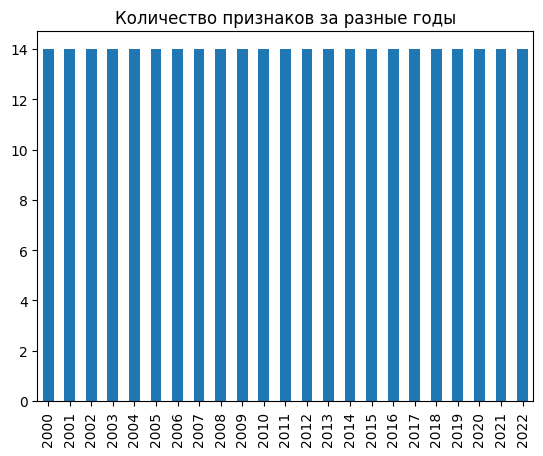

In [22]:
for key in Труд.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Труд[key] = new_df

total = set()
for key in Труд.keys():
    total.update(set(Труд[key].columns))

for key in Труд.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Труд[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Труд[year].columns) - 3 for year in Труд.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_03_socio_economic_102_v20240607 (Уровень жизни населения)

In [25]:
df = pd.read_excel('data_03_socio_economic_102_v20240607.xlsx')

In [26]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Уровень жизни населения,Y4170301010000,Реальные денежные доходы: Реальные доходы насе...,CD,Российская Федерация,страна,0,0,2000,113.4,в процентах к предыдущему году,До 2013 г. (для относительных показателей — до...,Регионы России. Социально-экономические показа...


In [27]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(df['subsection'].unique() == ['CD'])
    # оно здесь не выполнено
    print('ВЫПОЛНЕНО')
except:
    print('НЕ ВЫПОЛНЕНО')

НЕ ВЫПОЛНЕНО


In [28]:
needed_cols = np.array([k for k, v in df['indicator_name'].value_counts().items() if v >= 2093])

In [29]:
df = df[df['indicator_name'].isin(needed_cols)]
df = df[df['year'].isin(np.array(range(2000, 2023, 1)))]

In [30]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if list(df1['subsection'].unique()) == ['CD']:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    else:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'subsection', 'year', 'indicator_value', 'indicator_unit']]
        if name == 'Реальные денежные доходы: Реальный размер назначенных пенсий':
            df1 = df1[df1['subsection'] != 'Включая единовременную выплату']
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
            assert(len(df1['indicator_unit'].unique()) == 1)
            dfs.append(df1)
            continue
        if name == 'Средний размер назначенных пенсий':
            df1 = df1[df1['subsection'] != 'Включая единовременную выплату']
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
            df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
            assert(len(df1['indicator_unit'].unique()) == 1)
            dfs.append(df1)
            continue
        if name == 'Структура денежных доходов населения':
            for i in range(4):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        if name == 'Структура социальных выплат':
            for i in range(4):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        if name == 'Структура использования денежных доходов населения':
            for i in range(5):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        if name == 'Структура потребительских расходов домашних хозяйств':
            for i in range(4):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        else:
            print(name)
            continue
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [31]:
df = pd.concat(dfs, axis=0)

In [32]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [33]:
# инициализируем года
Уровень_жизни_населения = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:
~~~ Структура денежных доходов населения: Оплата труда (в процентах от общего объема денежных доходов)
~~~ Структура денежных доходов населения: Доходы от предпринимательской деятельности (в процентах от общего объема денежных доходов)


Text(0.5, 1.0, 'Количество признаков за разные годы')

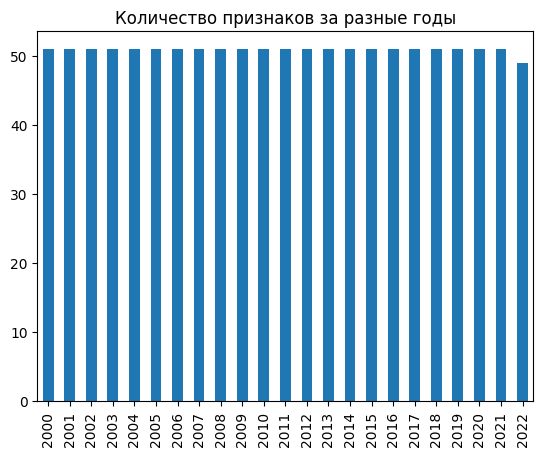

In [34]:
for key in Уровень_жизни_населения.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Уровень_жизни_населения[key] = new_df

total = set()
for key in Уровень_жизни_населения.keys():
    total.update(set(Уровень_жизни_населения[key].columns))

for key in Уровень_жизни_населения.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Уровень_жизни_населения[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Уровень_жизни_населения[year].columns) - 3 for year in Уровень_жизни_населения.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_04_socio_economic_102_v20240607 (Образование)

In [13]:
df = pd.read_excel('data_04_socio_economic_102_v20240607.xlsx')

In [14]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Образование,Y4170401000000,"Численность воспитанников организаций, осущест...",CD,Российская Федерация,страна,0,0,2000,4263.0,"на конец года, тысяч человек",Информация за 2021 год приведена с учетом инди...,Регионы России. Социально-экономические показа...


In [15]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [16]:
# оставляем только признаки реленвантные в 2000 году
needed = df[df['year'] == 2000]['indicator_name'].unique()
df = df[df['indicator_name'].isin(needed)]

In [17]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [18]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if (len(df1['year'].unique()) == 23):
        df1 = df1[['indicator_name', 'object_name', 'year', 'indicator_value', 'indicator_unit']]
        df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] >= 0, np.nan)
        assert(sorted(df1['year'].unique()) == [i for i in range(2000, 2023, 1)])
        assert(len(df1['indicator_unit'].unique()) == 1)
        dfs.append(df1)

In [19]:
# инициализируем года
Образование = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
~~~ Численность студентов государственных и муниципальных профессиональных образовательных организаций, обучающихся по программам подготовки специалистов среднего звена на 10 000 человек населения (на начало учебного года, человек)
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

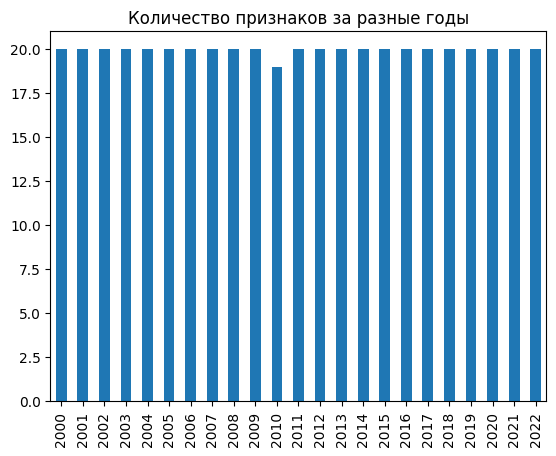

In [20]:
for key in Образование.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Образование[key] = new_df

total = set()
for key in Образование.keys():
    total.update(set(Образование[key].columns))

for key in Образование.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Образование[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Образование[year].columns) - 3 for year in Образование.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_05_socio_economic_102_v20240607 (Здравоохранение)

In [45]:
df = pd.read_excel('data_05_socio_economic_102_v20240607.xlsx')

In [46]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Здравоохранение,Y4170501010000,Число больничных коек: Всего,CD,Российская Федерация,страна,0,0,2000,1671.6,"на конец года, тысяч коек",2005 г. — включая койки дневных стационаров,Регионы России. Социально-экономические показа...


In [47]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [48]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [49]:
# инициализируем года
Здравоохранение = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Травмы, отравления и некоторые другие последствия воздействия внешних причин (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Новообразования (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Болезни эндокринной системы, расстройства питания и нарушения обмена веществ (зарегистрировано заболеваний у пациентов с диагнозом, установленным впервые в жизни)
~~~ Заболеваемость на 1000 человек населения по основным классам болезней: Болезни нервной системы (зарегистрировано заболеваний у пациентов с диагнозом, установлен

Text(0.5, 1.0, 'Количество признаков за разные годы')

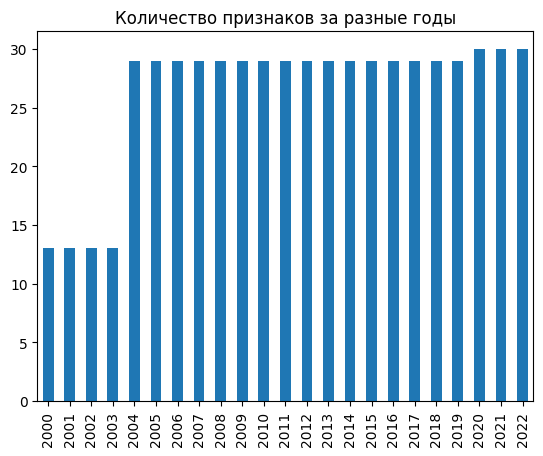

In [50]:
for key in Здравоохранение.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Здравоохранение[key] = new_df

total = set()
for key in Здравоохранение.keys():
    total.update(set(Здравоохранение[key].columns))

for key in Здравоохранение.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Здравоохранение[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Здравоохранение[year].columns) - 3 for year in Здравоохранение.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_06_socio_economic_102_v20240607 (Культура, отдых и туризм)

In [21]:
df = pd.read_excel('data_06_socio_economic_102_v20240607.xlsx')

In [22]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,"Культура, отдых и туризм",Y4170601010000,Численность зрителей театров и число посещений...,CD,Российская Федерация,страна,0,0,2000,210.0,человек,Расчет осуществлен на основе данных Минкультур...,Регионы России. Социально-экономические показа...


In [23]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [24]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [25]:
# инициализируем года
Культура_отдых_и_туризм = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность российских туристов, отправленных туристскими фирмами, в зарубежные туры (тысяч человек)
~~~ Численность отдохнувших детей в субъекте Российской Федерации (тысяч человек)
~~~ Туристские фирмы: Число турпакетов, реализованных населению (тысяч)
~~~ Туристские фирмы: Число туристских фирм (ND)
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность российских туристов, отправленных туристскими фирмами, в туры по России (тысяч человек)
~~~ Детские оздоровительные лагеря: Число детских оздоровительных лагерей в 2000‒2017 гг. (ND)
~~~ Детский отдых: Численность детей, отдохнувших в них за лето в 2000‒2017 гг. (тысяч человек)
В 2001 году не учлись:
~~~ Численность российских туристов, обслуженных туристскими фирмами: Численность российских туристов, отправленных туристскими фирмами, в зарубежные туры (тысяч человек)
~~~ Численность отдохнувших детей в субъекте Рос

Text(0.5, 1.0, 'Количество признаков за разные годы')

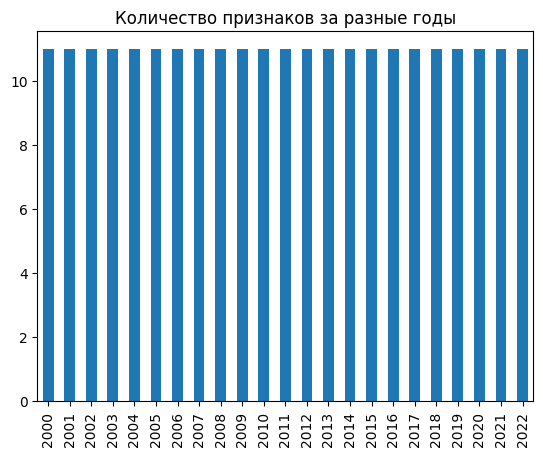

In [26]:
for key in Культура_отдых_и_туризм.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Культура_отдых_и_туризм[key] = new_df

total = set()
for key in Культура_отдых_и_туризм.keys():
    total.update(set(Культура_отдых_и_туризм[key].columns))

intersection = total
for key in Культура_отдых_и_туризм.keys():
    intersection = intersection.intersection(set(Культура_отдых_и_туризм[key].columns))


for key in Культура_отдых_и_туризм.keys():
    Культура_отдых_и_туризм[key] = Культура_отдых_и_туризм[key][list(intersection)]
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Культура_отдых_и_туризм[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Культура_отдых_и_туризм[year].columns) - 3 for year in Культура_отдых_и_туризм.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_07_socio_economic_102_v20240607 (Земельные ресурсы и охрана окружающей природной среды)

In [59]:
df = pd.read_excel('data_07_socio_economic_102_v20240607.xlsx')

In [60]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Земельные ресурсы и охрана окружающей природно...,Y4170701010000,Земельная площадь по видам угодий: Сельскохозя...,CD,Российская Федерация,страна,0,0,2005,220.7,"на конец года, тысяч га; для значений в целом ...",По данным Федеральной службы государственной р...,Регионы России. Социально-экономические показа...


In [61]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [62]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [63]:
# инициализируем года
Земля_и_охрана_природы = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
~~~ Земельная площадь по видам угодий: Лесные земли (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйственные угодья (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйстве (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Поверхностные воды, включая болота (на конец года, тысяч га; для значений в целом по России: млн га)
В 2001 году не учлись:
~~~ Земельная площадь по видам угодий: Лесные земли (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйственные угодья (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Сельскохозяйстве (на конец года, тысяч га; для значений в целом по России: млн га)
~~~ Земельная площадь по видам угодий: Поверхностные воды, включая б

Text(0.5, 1.0, 'Количество признаков за разные годы')

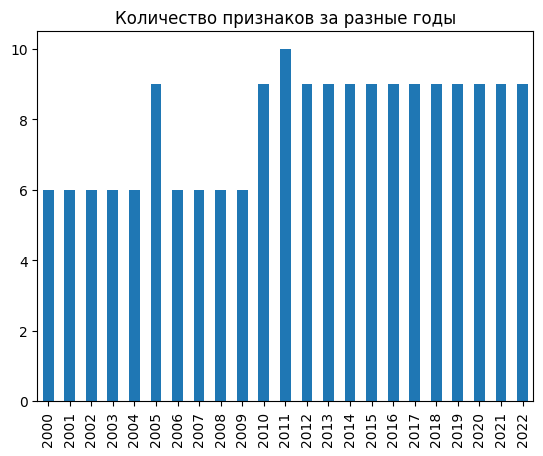

In [64]:
for key in Земля_и_охрана_природы.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Земля_и_охрана_природы[key] = new_df

total = set()
for key in Земля_и_охрана_природы.keys():
    total.update(set(Земля_и_охрана_природы[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Земля_и_охрана_природы[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Земля_и_охрана_природы[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_08_socio_economic_102_v20240607 (Валовой региональный продукт)

In [66]:
df = pd.read_excel('data_08_socio_economic_102_v20240607.xlsx')

In [67]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Валовой региональный продукт,Y4170801000000,Валовой региональный продукт,CD,Российская Федерация,страна,0,0,2000,5753671.6,миллионов рублей,CD,Регионы России. Социально-экономические показа...


In [68]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [69]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [70]:
# инициализируем года
ВРП = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2017 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2018 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2019 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 2020 году не учлись:
~~~ Валовое накопление основного капитала в 2000‒2015 гг. (в текущих рыночных ценах, миллионов рублей)
В 

Text(0.5, 1.0, 'Количество признаков за разные годы')

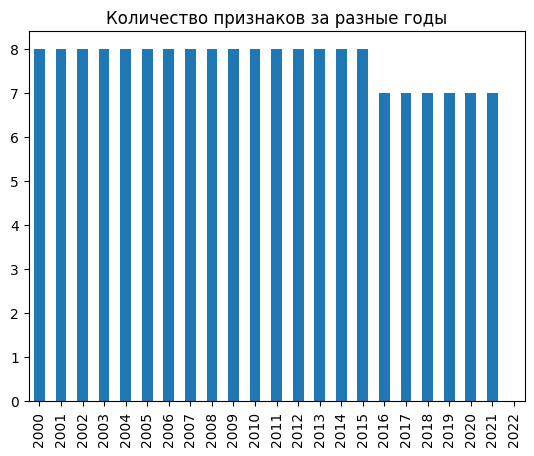

In [71]:
for key in ВРП.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    ВРП[key] = new_df

total = set()
for key in ВРП.keys():
    total.update(set(ВРП[key].columns))

for key in range(2000, 2023):
    if key == 2022:
        continue
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(ВРП[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(ВРП[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_09_socio_economic_102_v20240607 (Основные фонды)

In [74]:
df = pd.read_excel('data_09_socio_economic_102_v20240607.xlsx')

In [75]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Основные фонды,Y4170901000000,Стоимость основных фондов,CD,Российская Федерация,страна,0,0,2000,17464172.0,"на конец года, по полной учетной стоимости, ми...",С учетом проводившихся переоценок,Регионы России. Социально-экономические показа...


In [76]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [77]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [78]:
# инициализируем года
Основные_фонды = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:
~~~ Удельный вес полностью изношенных основных фондов в их общем объеме в 2000‒2021 гг. (на конец года, по полной учетной стоимости, в процентах)


Text(0.5, 1.0, 'Количество признаков за разные годы')

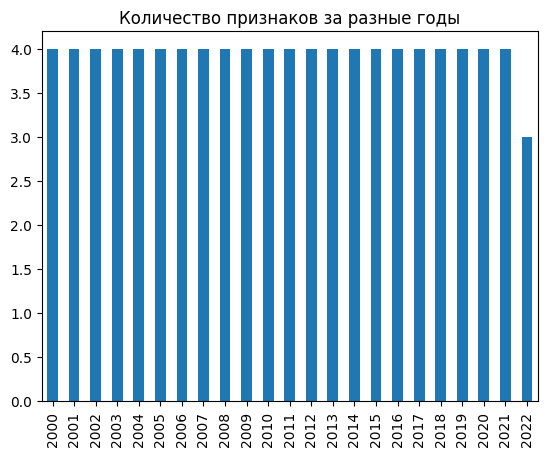

In [79]:
for key in Основные_фонды.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Основные_фонды[key] = new_df

total = set()
for key in Основные_фонды.keys():
    total.update(set(Основные_фонды[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Основные_фонды[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Основные_фонды[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_10_socio_economic_102_v20240607 (Инвестиции)

In [81]:
df = pd.read_excel('data_10_socio_economic_102_v20240607.xlsx')

In [82]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Инвестиции,Y4171001000000,Инвестиции в основной капитал,CD,Российская Федерация,страна,0,0,2000,1165234.0,"в фактически действовавших ценах, миллионов ру...",2022 г. — включая уточнение на федеральном уро...,Регионы России. Социально-экономические показа...


In [83]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [84]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [85]:
# инициализируем года
Инвестиции = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

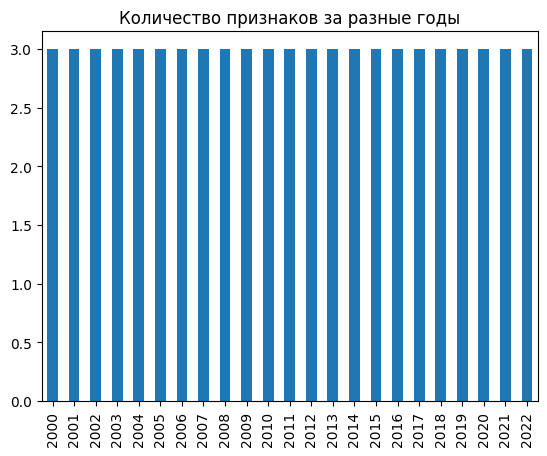

In [86]:
for key in Инвестиции.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Инвестиции[key] = new_df

########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Инвестиции.keys():
    total.update(set(Инвестиции[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Инвестиции[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Инвестиции[key]['object_name']
    buff_df['object_level'] = Инвестиции[key]['object_level']
    buff_df['year'] = Инвестиции[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Инвестиции[key][feature]
    
    Инвестиции[key] = buff_df
#########################

total = set()
for key in Инвестиции.keys():
    total.update(set(Инвестиции[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Инвестиции[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Инвестиции[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_11_socio_economic_102_v20240607 (Предприятия и организации)

In [88]:
df = pd.read_excel('data_11_socio_economic_102_v20240607.xlsx')

In [89]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Предприятия и организации,Y4171101000000,Число организаций,CD,Российская Федерация,страна,0,0,2000,3346483.0,на конец года,По данным государственной регистрации,Регионы России. Социально-экономические показа...


In [90]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [91]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [92]:
# инициализируем года
Предприятия_и_организации = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

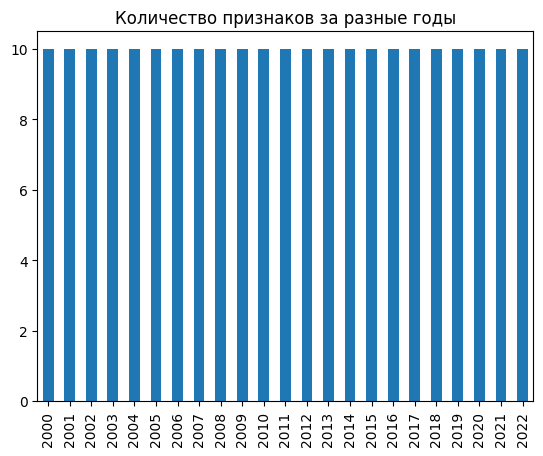

In [93]:
for key in Предприятия_и_организации.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Предприятия_и_организации[key] = new_df


#########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Предприятия_и_организации.keys():
    total.update(set(Предприятия_и_организации[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Предприятия_и_организации[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Предприятия_и_организации[key]['object_name']
    buff_df['object_level'] = Предприятия_и_организации[key]['object_level']
    buff_df['year'] = Предприятия_и_организации[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Предприятия_и_организации[key][feature]
    
    Предприятия_и_организации[key] = buff_df
#########################


total = set()
for key in Предприятия_и_организации.keys():
    total.update(set(Предприятия_и_организации[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Предприятия_и_организации[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Предприятия_и_организации[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_12_socio_economic_102_v20240607 (НЕ СФОРМИРОВАНО - Промышленное производство)

# data_13_socio_economic_102_v20240607 (Сельское, лесное хозяйство, рыболовство и рыбоводство)

In [97]:
df = pd.read_excel('data_13_socio_economic_102_v20240607.xlsx')

In [98]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,"Сельское, лесное хозяйство, рыболовство и рыбо...",Y4171301000000,Продукция сельского хозяйства,CD,Российская Федерация,страна,0,0,2000,742424.398,"в хозяйствах всех категорий, в фактически дейс...",Изменения внесены в связи с получением итогов ...,Регионы России. Социально-экономические показа...


In [99]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [100]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [101]:
Сельхоз_и_рыболовство = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

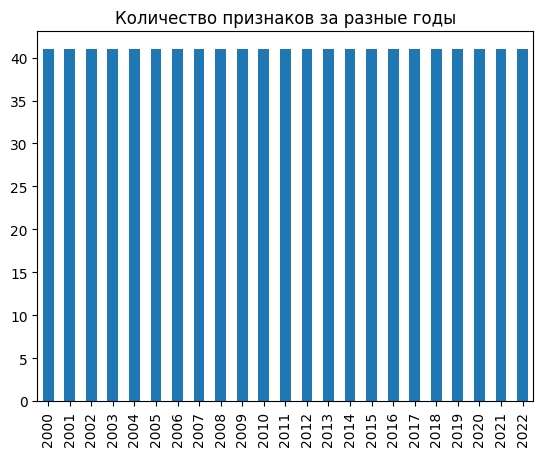

In [102]:
for key in Сельхоз_и_рыболовство.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Сельхоз_и_рыболовство[key] = new_df


#########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Сельхоз_и_рыболовство.keys():
    total.update(set(Сельхоз_и_рыболовство[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Сельхоз_и_рыболовство[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Сельхоз_и_рыболовство[key]['object_name']
    buff_df['object_level'] = Сельхоз_и_рыболовство[key]['object_level']
    buff_df['year'] = Сельхоз_и_рыболовство[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Сельхоз_и_рыболовство[key][feature]
    
    Сельхоз_и_рыболовство[key] = buff_df
#########################


total = set()
for key in Сельхоз_и_рыболовство.keys():
    total.update(set(Сельхоз_и_рыболовство[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Сельхоз_и_рыболовство[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Сельхоз_и_рыболовство[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_14_socio_economic_102_v20240607 (Строительство)

In [104]:
df = pd.read_excel('data_14_socio_economic_102_v20240607.xlsx')

In [105]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Строительство,Y4171401000000,"Объем работ, выполненных по виду экономической...",CD,Российская Федерация,страна,0,0,2000,503836.8,"в фактически действовавших ценах, миллионов ру...",2022 г. — сводные итоги по Российской Федераци...,Регионы России. Социально-экономические показа...


In [106]:
# если не выполнено, то требуется ручная обработка
try:
    assert(df['subsection'].unique() == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНО!!!")

НЕ ВЫПОЛНЕНО!!!


In [107]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [108]:
df = df[df['indicator_name'] != 'Число зданий и сооружений, находящихся в незавершенном строительстве']

In [109]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if list(df1['subsection'].unique()) == ['CD']:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    else:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'subsection', 'year', 'indicator_value', 'indicator_unit']]
        if name == 'Жилые дома, находящиеся в незавершенном строительстве':
            for i in range(2):
                df0 = df1[df1['subsection'] == df1['subsection'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + ': ' + df0['subsection']
                assert(len(df0['indicator_unit'].unique()) == 1)
                dfs.append(df0)
            continue
        else:
            print(name)
            continue
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [110]:
df = pd.concat(dfs, axis=0)

In [111]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [112]:
# инициализируем года
Строительство = {year : None for year in df['year'].unique()}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

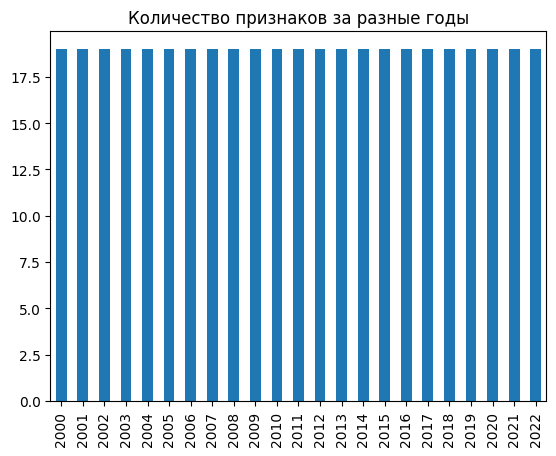

In [113]:
for key in Строительство.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Строительство[key] = new_df

total = set()
for key in Строительство.keys():
    total.update(set(Строительство[key].columns))

for key in Строительство.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Строительство[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Строительство[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_15_socio_economic_102_v20240607 (Торговля и услуги населению)

In [115]:
df = pd.read_excel('data_15_socio_economic_102_v20240607.xlsx')

In [116]:
df.head(1)

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Торговля и услуги населению,Y4171501000000,Оборот розничной торговли,CD,Российская Федерация,страна,0,0,2000,2352.3,"в фактически действовавших ценах, миллионов ру...",CD,Регионы России. Социально-экономические показа...


In [117]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [118]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [119]:
Торговля_и_услуги_населению = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

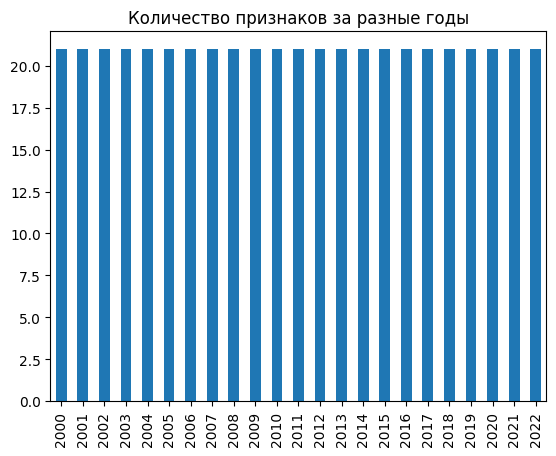

In [120]:
for key in Торговля_и_услуги_населению.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Торговля_и_услуги_населению[key] = new_df


#########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Торговля_и_услуги_населению.keys():
    total.update(set(Торговля_и_услуги_населению[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Торговля_и_услуги_населению[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Торговля_и_услуги_населению[key]['object_name']
    buff_df['object_level'] = Торговля_и_услуги_населению[key]['object_level']
    buff_df['year'] = Торговля_и_услуги_населению[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Торговля_и_услуги_населению[key][feature]
    
    Торговля_и_услуги_населению[key] = buff_df
#########################


total = set()
for key in Торговля_и_услуги_населению.keys():
    total.update(set(Торговля_и_услуги_населению[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Торговля_и_услуги_населению[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Торговля_и_услуги_населению[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_16_socio_economic_102_v20240607 (Транспорт)

In [122]:
df = pd.read_excel('data_16_socio_economic_102_v20240607.xlsx')

In [123]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2000,1046.794,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
1,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2001,1057.516,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
2,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2002,1083.700,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
3,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2003,1160.934,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...
4,Транспорт,Y4171601000000,Отправление грузов железнодорожным транспортом...,CD,Российская Федерация,страна,0,0,2004,1221.164,миллионов тонн,"Включая данные, не распределенные по субъектам...",Регионы России. Социально-экономические показа...


In [124]:
# если не выполнено, то требуется ручная обработка
assert(df['subsection'].unique() == ['CD'])

In [125]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [126]:
Транспорт = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

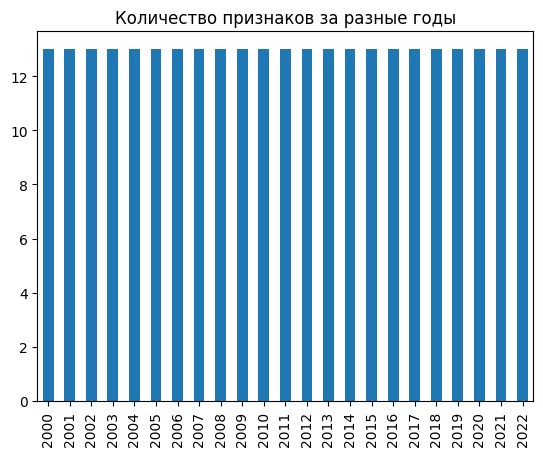

In [127]:
for key in Транспорт.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Транспорт[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Транспорт.keys():
#     total.update(set(Транспорт[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Транспорт[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Транспорт[key]['object_name']
#     buff_df['object_level'] = Транспорт[key]['object_level']
#     buff_df['year'] = Транспорт[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Транспорт[key][feature]
    
#     Транспорт[key] = buff_df
# #########################


total = set()
for key in Транспорт.keys():
    total.update(set(Транспорт[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Транспорт[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Транспорт[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_17_socio_economic_102_v20240607 (НЕ СФОРМИРОВАНО - Информационные и коммуникационные технологии)

# data_18_socio_economic_102_v20240607 (Наука и инновации)

In [131]:
df = pd.read_excel('data_18_socio_economic_102_v20240607.xlsx')

In [132]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2000,4099.0,ND,CD,Регионы России. Социально-экономические показа...
1,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2001,4037.0,ND,CD,Регионы России. Социально-экономические показа...
2,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2002,3906.0,ND,CD,Регионы России. Социально-экономические показа...
3,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2003,3797.0,ND,CD,Регионы России. Социально-экономические показа...
4,Наука и инновации,Y4171801000000,"Организации, выполнявшие научные исследования ...",CD,Российская Федерация,страна,0,0,2004,3656.0,ND,CD,Регионы России. Социально-экономические показа...


In [133]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

НЕ ВЫПОЛНЕНЕНО!!!


In [134]:
df = df[df['subsection'] == 'CD']
df = df[df['indicator_name'] != 'Инновационная активность организации: Уровень инновационной активности организаций']
df = df[df['indicator_name'] != 'Инновационная активность организаций: Удельный вес организаций, осуществлявших технологические инновации, в общем числе обследованных организаций']

In [135]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [136]:
Наука_и_инновации = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

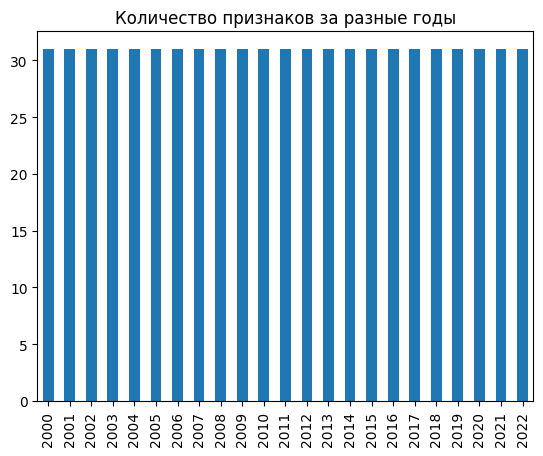

In [137]:
for key in Наука_и_инновации.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Наука_и_инновации[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Наука_и_инновации.keys():
#     total.update(set(Наука_и_инновации[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Наука_и_инновации[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Наука_и_инновации[key]['object_name']
#     buff_df['object_level'] = Наука_и_инновации[key]['object_level']
#     buff_df['year'] = Наука_и_инновации[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Наука_и_инновации[key][feature]
    
#     Наука_и_инновации[key] = buff_df
# #########################


total = set()
for key in Наука_и_инновации.keys():
    total.update(set(Наука_и_инновации[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Наука_и_инновации[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Наука_и_инновации[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_19_socio_economic_102_v20240607 (Финансы - но это не "та самая" часть)

In [51]:
df = pd.read_excel('data_19_socio_economic_102_v20240607.xlsx')

In [52]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Российской Федерации,CD,Российская Федерация,страна,0,0,2000,1065.8,миллионов рублей; для значений в целом по России: млрд руб,По данным Федерального казначейства,Регионы России. Социально-экономические показатели 2023
1,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Российской Федерации,CD,Российская Федерация,страна,0,0,2001,1322.4,миллионов рублей; для значений в целом по России: млрд руб,По данным Федерального казначейства,Регионы России. Социально-экономические показатели 2023
2,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Российской Федерации,CD,Российская Федерация,страна,0,0,2002,1633.6,миллионов рублей; для значений в целом по России: млрд руб,По данным Федерального казначейства,Регионы России. Социально-экономические показатели 2023
3,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Российской Федерации,CD,Российская Федерация,страна,0,0,2003,1930.5,миллионов рублей; для значений в целом по России: млрд руб,По данным Федерального казначейства,Регионы России. Социально-экономические показатели 2023
4,Финансы,Y4171901000000,Доходы консолидированных бюджетов субъектов Российской Федерации,CD,Российская Федерация,страна,0,0,2004,2403.2,миллионов рублей; для значений в целом по России: млрд руб,По данным Федерального казначейства,Регионы России. Социально-экономические показатели 2023


In [53]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

ВЫПОЛНЕНО


In [54]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [55]:
Финансы = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

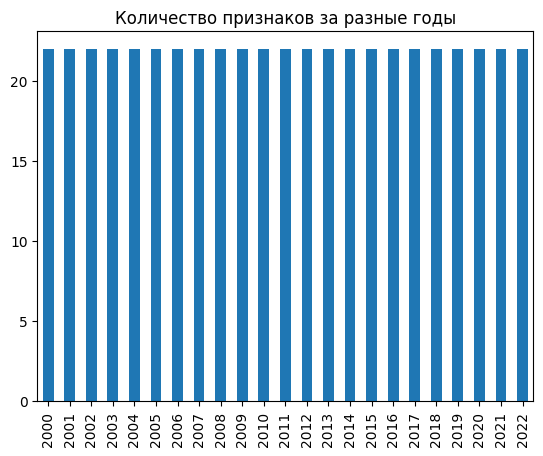

In [56]:
for key in Финансы.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Финансы[key] = new_df


########################
# сразу выбираем только те признаки, которые есть для всех годов
total = set()
for key in Финансы.keys():
    total.update(set(Финансы[key].columns))

for key in range(2000, 2023):
    total = total.intersection(set(Финансы[key].columns))
total = np.array(list(total))

for key in range(2000, 2023):
    buff_df = pd.DataFrame()
    buff_df['object_name'] = Финансы[key]['object_name']
    buff_df['object_level'] = Финансы[key]['object_level']
    buff_df['year'] = Финансы[key]['year']

    for feature in sorted(total):
        buff_df[feature] = Финансы[key][feature]
    
    Финансы[key] = buff_df
#########################


total = set()
for key in Финансы.keys():
    total.update(set(Финансы[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Финансы[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Финансы[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_20_socio_economic_102_v20240607 (Цены и тарифы)

In [146]:
df = pd.read_excel('data_20_socio_economic_102_v20240607.xlsx')

In [147]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2000,120.2,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
1,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2001,118.6,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
2,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2002,115.1,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
3,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2003,112.0,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...
4,Цены и тарифы,Y4172001000000,Индексы потребительских цен,CD,Российская Федерация,страна,0,0,2004,111.7,"декабрь к декабрю предыдущего года, в процентах",Данные за 2014 г. приведены без учета сведений...,Регионы России. Социально-экономические показа...


In [148]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

ВЫПОЛНЕНО


In [149]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [150]:
neeeded = df['indicator_name'].value_counts()[df['indicator_name'].value_counts() >= 2208].index
df = df[df['indicator_name'].isin(neeeded)]

In [151]:
dfs = []

for name in df['indicator_name'].unique():
    df1 = df[df['indicator_name'] == name]
    if len(list(df1['indicator_unit'].unique())) == 1:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
    else:
        df1 = df1[['indicator_name', 'object_name', 'object_level', 'year', 'indicator_value', 'indicator_unit']]
        if name == 'Стоимость фиксированного набора потребительских товаров и услуг: Стоимость фиксированного набора':
            for i in range(2):
                df0 = df1[df1['indicator_unit'] == df1['indicator_unit'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + f' (option_{i})'
                dfs.append(df0)
            continue
        if name == 'Стоимость условного (минимального) набора продуктов питания: Стоимость минимального набора':
            for i in range(2):
                df0 = df1[df1['indicator_unit'] == df1['indicator_unit'].unique()[i]].copy()
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -99999999, np.nan)
                df0['indicator_value'] = df0['indicator_value'].where(df0['indicator_value'] != -77777777, np.nan)
                df0['indicator_name'] = df0['indicator_name'] + f' (option_{i})'
                dfs.append(df0)
            continue
        else:
            print(name)
            continue
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -99999999, np.nan)
    df1['indicator_value'] = df1['indicator_value'].where(df1['indicator_value'] != -77777777, np.nan)
    assert(len(df1['indicator_unit'].unique()) == 1)
    dfs.append(df1)

In [152]:
df = pd.concat(dfs, axis=0)

In [153]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [154]:
Цены_и_тарифы = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:


Text(0.5, 1.0, 'Количество признаков за разные годы')

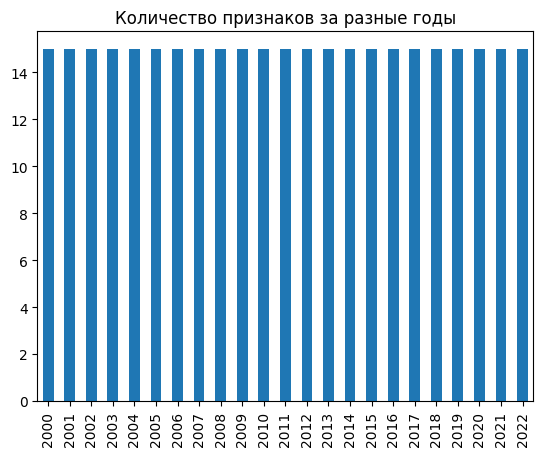

In [155]:
for key in Цены_и_тарифы.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    assert(len(new_df) == 96)
    Цены_и_тарифы[key] = new_df

total = set()
for key in Цены_и_тарифы.keys():
    total.update(set(Цены_и_тарифы[key].columns))

for key in Цены_и_тарифы.keys():
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Цены_и_тарифы[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Цены_и_тарифы[year].columns) - 3 for year in Цены_и_тарифы.keys()}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# data_21_socio_economic_102_v20240607 (Внешняя торговля)

In [157]:
df = pd.read_excel('data_21_socio_economic_102_v20240607.xlsx')

In [158]:
df.head()

,section,indicator_code,indicator_name,subsection,object_name,object_level,object_oktmo,object_okato,year,indicator_value,indicator_unit,comment,source
0,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2000,89269.2,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
1,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2001,85352.2,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
2,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2002,90545.5,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
3,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2003,113157.0,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...
4,Внешняя торговля,Y4172101010000,Внешняя торговля со странами дальнего зарубежь...,CD,Российская Федерация,страна,0,0,2004,152248.0,"в фактически действовавших ценах, миллионов до...",В связи с приостановкой публикации данных стат...,Регионы России. Социально-экономические показа...


In [159]:
try:
    # если не выполнено, то требуется ручная обработка
    assert(list(df['subsection'].unique()) == ['CD'])
    print("ВЫПОЛНЕНО")
except:
    print("НЕ ВЫПОЛНЕНЕНО!!!")

ВЫПОЛНЕНО


In [160]:
# все пропуски помечены как np.nan
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -99999999, np.nan)
df['indicator_value'] = df['indicator_value'].where(df['indicator_value'] != -77777777, np.nan)

In [161]:
Внешняя_торговля = {year : None for year in range(2000, 2023)}

В 2000 году не учлись:
В 2001 году не учлись:
В 2002 году не учлись:
В 2003 году не учлись:
В 2004 году не учлись:
В 2005 году не учлись:
В 2006 году не учлись:
В 2007 году не учлись:
В 2008 году не учлись:
В 2009 году не учлись:
В 2010 году не учлись:
В 2011 году не учлись:
В 2012 году не учлись:
В 2013 году не учлись:
В 2014 году не учлись:
В 2015 году не учлись:
В 2016 году не учлись:
В 2017 году не учлись:
В 2018 году не учлись:
В 2019 году не учлись:
В 2020 году не учлись:
В 2021 году не учлись:
В 2022 году не учлись:
~~~ Внешняя торговля со странами дальнего зарубежья: Экспорт (в фактически действовавших ценах, миллионов долларов США)
~~~ Внешняя торговля со странами дальнего зарубежья: Импорт (в фактически действовавших ценах, миллионов долларов США)
~~~ Внешняя торговля со странами СНГ: Импорт (в фактически действовавших ценах, миллионов долларов США)
~~~ Внешняя торговля со странами СНГ: Экспорт (в фактически действовавших ценах, миллионов долларов США)


Text(0.5, 1.0, 'Количество признаков за разные годы')

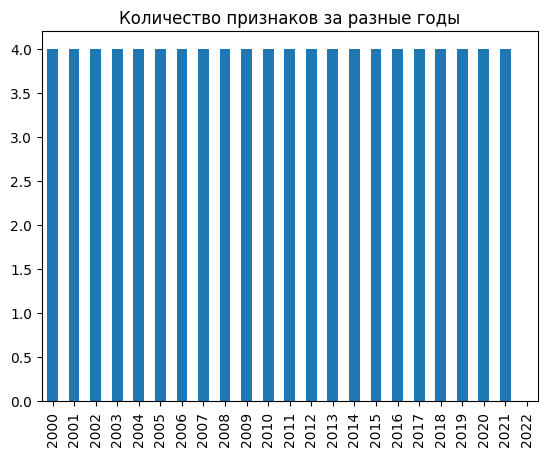

In [162]:
for key in Внешняя_торговля.keys():
    current_df = df[df['year'] == key].copy()
    current_df.loc[:,'feature_name'] = current_df['indicator_name'] + ' (' + current_df['indicator_unit'] + ')'

    # собсвтенно генерация датасета для значения в словаре
    new_df = pd.DataFrame()
    new_df['object_name'] = current_df['object_name'].unique()
    new_df['object_level'] = pd.merge(left=new_df, right=current_df, on='object_name', how='right')['object_level']
    new_df['year'] = key
    for feature_name in sorted(current_df['feature_name'].unique()):
        new_df[feature_name] = pd.merge(left=new_df, right=current_df[current_df['feature_name'] == feature_name], on='object_name', how='right')['indicator_value']

    # проверка, что все регионы были включены 
    Внешняя_торговля[key] = new_df


#########################
# # сразу выбираем только те признаки, которые есть для всех годов
# total = set()
# for key in Внешняя_торговля.keys():
#     total.update(set(Внешняя_торговля[key].columns))

# for key in range(2000, 2023):
#     total = total.intersection(set(Внешняя_торговля[key].columns))
# total = np.array(list(total))

# for key in range(2000, 2023):
#     buff_df = pd.DataFrame()
#     buff_df['object_name'] = Внешняя_торговля[key]['object_name']
#     buff_df['object_level'] = Внешняя_торговля[key]['object_level']
#     buff_df['year'] = Внешняя_торговля[key]['year']

#     for feature in sorted(total):
#         buff_df[feature] = Внешняя_торговля[key][feature]
    
#     Внешняя_торговля[key] = buff_df
# #########################


total = set()
for key in Внешняя_торговля.keys():
    total.update(set(Внешняя_торговля[key].columns))

for key in range(2000, 2023):
    print(f"В {key} году не учлись:")
    for feature in total.difference(set(Внешняя_торговля[key].columns)):
        print(f"~~~ {feature}")

pd.Series({year : len(Внешняя_торговля[year].columns) - 3 for year in range(2000, 2023)}).plot(kind='bar')
plt.title('Количество признаков за разные годы')

# PREPROCESSING

In [183]:
my = [
    Инвестиции,
    Торговля_и_услуги_населению,
    Финансы,
    Цены_и_тарифы
]

In [184]:
def report_missing_values(subsystem, start_year=2000, end_year=2022):
    results = {}
    for year in range(start_year, end_year+1):
        results[year] = subsystem[year].isnull().sum().sum()
    sns.barplot(y=results.values(), x=results.keys())
    plt.xticks(rotation=90)

In [178]:
Инвестиции[2001][Инвестиции[2001].isnull().any(axis=1)]

,object_name,object_level,year,"Инвестиции в основной капитал (в фактически действовавших ценах, миллионов рублей)","Инвестиции в основной капитал на душу населения (в фактически действовавших ценах, рублей)","Индекс физического объема инвестиций в основной капитал (в сопоставимых ценах, в процентах к предыдущему году)"
25,Архангельская область без автономного округа,регион,2001,NaN,NaN,NaN
36,Республика Крым,регион,2001,NaN,NaN,NaN
41,Севастополь,регион,2001,NaN,NaN,NaN
71,Тюменская область без автономных округов,регион,2001,NaN,NaN,NaN


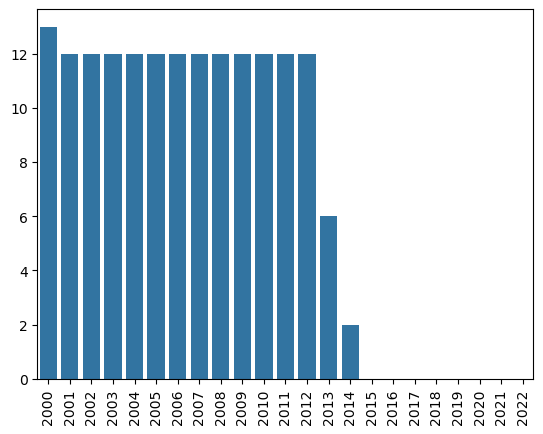

In [172]:
report_missing_values(my[0])

# Тест на примере population, culture, education

In [36]:
# current_states = [
#     Население,
#     Образование,
#     Культура_отдых_и_туризм
# ]

### Задаются функции

In [103]:
# выкидываем пропуски
def drop_missing_values(df, reference_columns):
    df_cleaned = df.dropna()
    df_cleaned = df_cleaned[reference_columns]
    
    return df_cleaned

def normalized_dict_by_minmax(dict_of_years: dict[int, pd.DataFrame]):
    neutral = (
        'object_name',
        'object_level',
        'year'
    )

    normilized_dict = {}
    for year in dict_of_years.keys():
        normilized_dict[year] = dict_of_years[year].copy()
        for category in normilized_dict[year].columns:
            if category in neutral:
                continue
            normilized_dict[year][category] = (normilized_dict[year][category] - normilized_dict[year][category].min()) / (normilized_dict[year][category].max() - normilized_dict[year][category].min())
    return normilized_dict

def normalized_dict_by_minmax_by_base_year(dict_of_years: dict[int, pd.DataFrame], base_year=2010):
    min_values_by_features = {}
    max_values_by_features = {}
    neutral = (
        'object_name',
        'object_level',
        'year'
    )

    for category in dict_of_years[base_year].columns:
        if category in neutral:
            continue
        min_values_by_features[category] = dict_of_years[base_year][category].min()
        max_values_by_features[category] = dict_of_years[base_year][category].max()

    normilized_dict = {}
    for year in dict_of_years.keys():
        normilized_dict[year] = dict_of_years[year].copy()
        for category in normilized_dict[year].columns:
            if category in neutral:
                continue
            normilized_dict[year][category] = (normilized_dict[year][category] - min_values_by_features[category]) / (max_values_by_features[category] - min_values_by_features[category])
    return normilized_dict

def calculate_index_with_weights(dict_of_dataframes):
    indexed_data = {}
    combined_data = pd.concat(dict_of_dataframes.values())
    numerical_columns = combined_data.drop(columns=['object_name', 'object_level', 'year'])
    
    pca = PCA(n_components=1)
    pca.fit(numerical_columns)
    weights = np.abs(pca.components_[0])

    weights /= weights.sum()
    
    for year, df in dict_of_dataframes.items():
        numerical_columns = df.drop(columns=['object_name', 'object_level', 'year'])
        weighted_mean = (numerical_columns * weights).sum(axis=1)
        df['index'] = weighted_mean
        indexed_data[year] = df[['object_name', 'index']]
    
    combined_index = pd.DataFrame()
    for year, df in indexed_data.items():
        df = df.set_index('object_name')['index']
        combined_index[year] = df

    return combined_index, weights

def combine_indices(df1, df2, alpha):
    if not df1.shape == df2.shape:
        raise ValueError("Датафреймы должны иметь одинаковую структуру (размеры и индексы).")
    if not (df1.index.equals(df2.index) and df1.columns.equals(df2.columns)):
        raise ValueError("Датафреймы должны иметь одинаковые индексы и столбцы.")

    if not (0 <= alpha <= 1):
        raise ValueError("Alpha должен быть в пределах от 0 до 1.")

    combined_df = alpha * df1 + (1 - alpha) * df2
    return combined_df

def plot_index_trends_multi(dfs_by_base, dfs_by_current, dfs_final, region, domen):
    if not (dfs_by_base.index.equals(dfs_by_current.index) and dfs_by_current.index.equals(dfs_final.index)):
        raise ValueError("Индексы регионов должны совпадать во всех датасетах.")
    
    region_name = region
    base_index = dfs_by_base.loc[region]
    current_index = dfs_by_current.loc[region]
    final_index = dfs_final.loc[region]
    plt.figure(figsize=(14, 8))
    plt.plot(final_index.index, final_index.values, marker='o', linestyle='-', linewidth=3,
             label="Final Index", color='red', alpha=0.9)  # Основной индекс
    plt.plot(base_index.index, base_index.values, marker='o', linestyle='--', linewidth=2,
             label="Base Index", color='blue', alpha=0.5)
    plt.plot(current_index.index, current_index.values, marker='o', linestyle=':', linewidth=2,
             label="Current Index", color='green', alpha=0.5)
    plt.title(f"{domen}. Динамика индексов по годам для региона: {region_name}", fontsize=16, fontweight='bold')
    plt.xlabel("Год", fontsize=14)
    plt.ylabel("Индекс", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    for i in range(len(final_index)):
        plt.annotate(f"{final_index.values[i]:.2f}", 
                     (final_index.index[i], final_index.values[i]),
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', fontsize=10, color='red')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.gca().set_facecolor('#f9f9f9')
    
    plt.show()

def plot_index_trends_with_similar(dfs_by_base, dfs_by_current, dfs_final, region_name, domen, k=3):
    if not (dfs_by_base.index.equals(dfs_by_current.index) and dfs_by_current.index.equals(dfs_final.index)):
        raise ValueError("Индексы регионов должны совпадать во всех датасетах.")
    if region_name not in dfs_final.index:
        raise ValueError(f"Регион '{region_name}' отсутствует в данных.")
    target_vector = dfs_final.loc[region_name].values.reshape(1, -1)
    distances = cdist(target_vector, dfs_final.values, metric='euclidean').flatten()
    similar_indices = np.argsort(distances)[1:k + 1]
    similar_regions = dfs_final.index[similar_indices]
    plt.figure(figsize=(14, 8))
    plt.gca().set_facecolor('white') 
    plt.grid(color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.plot(dfs_final.columns, dfs_final.loc[region_name], 
             marker='o', linestyle='-', linewidth=3, label=f"{region_name} (Target)", 
             color='orange', alpha=0.9, zorder=5) 
    
    colors = ['#FF6347', '#4682B4', '#32CD32', '#FFD700', '#8A2BE2']
    
    for i, similar_region in enumerate(similar_regions):
        plt.plot(dfs_final.columns, dfs_final.loc[similar_region], 
                 marker='s', linestyle=':', linewidth=2, label=similar_region,
                 color=colors[i % len(colors)], alpha=0.8)

        max_value = dfs_final.loc[similar_region].max()
        min_value = dfs_final.loc[similar_region].min()
        max_index = dfs_final.loc[similar_region].idxmax()
        min_index = dfs_final.loc[similar_region].idxmin()
        
        plt.scatter(max_index, max_value, color=colors[i % len(colors)], s=100, zorder=10, edgecolor='black', marker='o')
        plt.scatter(min_index, min_value, color=colors[i % len(colors)], s=100, zorder=10, edgecolor='black', marker='^')

    max_value_target = dfs_final.loc[region_name].max()
    min_value_target = dfs_final.loc[region_name].min()
    max_index_target = dfs_final.loc[region_name].idxmax()
    min_index_target = dfs_final.loc[region_name].idxmin()
    plt.scatter(max_index_target, max_value_target, color='orange', s=100, zorder=10, edgecolor='black', marker='o', label='Максимум')
    plt.scatter(min_index_target, min_value_target, color='orange', s=100, zorder=10, edgecolor='black', marker='^', label='Минимум')
    plt.title(f"{domen}. Динамика индексов для региона '{region_name}' и {k} похожих регионов", fontsize=18, fontweight='bold', color='#333')
    plt.xlabel("Год", fontsize=14)
    plt.ylabel("Индекс", fontsize=14)
    
    plt.legend(fontsize=12, loc="best")
    plt.xticks(rotation=45)
    
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.show()

def plot_top_successful_regions_dynamic(dfs_final, domen, top_n=10, alpha=0.5):
    """
    Строит горизонтальную диаграмму топ-N самых успешных регионов, учитывая уровень индекса за последний год и динамику.
    Добавлены декоративные элементы для улучшения визуализации.
    
    Args:
        dfs_final (pd.DataFrame): Датафрейм с индексами регионов (индексы - регионы, колонки - годы).
        top_n (int): Количество самых успешных регионов для отображения.
        alpha (float): Вес для динамики (0 <= alpha <= 1). 
                       Вес уровня последнего года = 1 - alpha.
    """
    if not (0 <= alpha <= 1):
        raise ValueError("Параметр alpha должен быть в диапазоне от 0 до 1.")
    
    index_growth = dfs_final.diff(axis=1).mean(axis=1)
    last_year = dfs_final.columns[-1]
    last_year_index = dfs_final[last_year]
    combined_score = alpha * index_growth + (1 - alpha) * last_year_index
    top_regions = combined_score.sort_values(ascending=False).head(top_n)
    norm = plt.Normalize(min(top_regions), max(top_regions))
    cmap = matplotlib.colormaps['coolwarm']
    
    fig, ax = plt.subplots(figsize=(12, 7))  # Создаем ось ax
    bars = ax.barh(top_regions.sort_values().index, top_regions.sort_values(), color=cmap(norm(top_regions.sort_values())))
    
    for bar in bars:
        bar.set_edgecolor('black')
        bar.set_linewidth(1.5) 
        for i, (region, value) in enumerate(zip(top_regions.sort_values().index, top_regions.sort_values())):
            ax.text(value + 0.01, i, f"({value:.3f})", va='center', fontsize=12, color='black', weight='bold')
    
    ax.set_title(f"{domen}. Топ-{top_n} самых успешных регионов с учетом динамики ({last_year})", fontsize=16, weight='bold')
    ax.set_xlabel("Куммулятивный рейтинг", fontsize=14)
    ax.set_ylabel("Регионы", fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def mean_weight(weights_by_base, weights_by_current, alpha=0.9):
    return weights_by_base * alpha + (1 - alpha) * weights_by_current

### Блок вычислений

**Эталон обработки**

In [11]:
neutral = [
    'object_name',
    'object_level',
    'year',
]

stimulants = [
    'Коэффициенты естественного прироста населения на 1000 человек населения (ND)',
    'Суммарный коэффициент рождаемости (число детей на 1 женщину)',
    'Ожидаемая продолжительность жизни при рождении: Все население (число лет)',
    'Ожидаемая продолжительность жизни при рождении: Женщины (число лет)',
    'Ожидаемая продолжительность жизни при рождении: Мужчины (число лет)',
    'Удельный вес городского населения в общей численности населения (оценка на конец года, в процентах)',
]

destimulants = [
    'Коэффициенты демографической нагрузки: Всего (оценка на конец года, на 1000 человек трудоспособного возраста приходится лиц нетрудоспособных возрастов)',
    'Смертность населения в трудоспособном возрасте (число умерших на 100 000 человек соответствующего возраста)',
    'Соотношение браков и разводов (на 1000 браков приходится разводов)',
    'Коэффициенты младенческой смертности (число детей, умерших в возрасте до 1 года, на 1000 родившихся живыми)',
    'Общие коэффициенты смертности (число умерших на 1000 человек населения)',
]

others = [
]

# нейтральные добавляются как есть
population = {year : Население[year][neutral].copy() for year in Население.keys()}

# стимулянты добавляются как есть
for year, data in population.items():
    for stim in stimulants:
        data[stim] = Население[year][stim]
    

# дестимулянты инвертируется
for year, data in population.items():
    for destim in destimulants:
        data[destim] = -Население[year][destim]

# другие пока не учитываются

In [1372]:
neutral = [
    'object_name',
    'object_level',
    'year'
]

stimulants = [
    'Валовой коэффициент охвата дошкольным образованием (на конец года, в процентах от численности детей в возрасте 1‒6 лет)',
    'Выпуск бакалавров, специалистов, магистров (тысяч человек)',
    # 'Выпуск квалифицированных рабочих и служащих (тысяч человек)',
    # 'Выпуск обучающихся организациями, осуществляющих образовательную деятельность по образовательным программам начального, основного и среднего общего образования: Выпуск обучающихся с аттестатом о среднем общем образовании (тысяч человек)',
    # 'Выпуск обучающихся организациями, осуществляющих образовательную деятельность по образовательным программам начального, основного и среднего общего образования: Выпуск обучающихся с аттестатом об основном общем образовании (тысяч человек)',
    # 'Выпуск специалистов среднего звена (тысяч человек)',
    'Обеспеченность детей дошкольного возраста местами в организациях, осуществляющих образовательную деятельность по образовательным программам дошкольного образования, присмотр и уход за детьми (на конец года, приходится мест на 1000 детей)',
    'Прием на обучение по программам бакалавриата, специалитета, магистратуры (тысяч человек)',
    # 'Прием на обучение по программам подготовки квалифицированных рабочих, служащих (тысяч человек)',
    # 'Прием на обучение по программам подготовки специалистов среднего звена (тысяч человек)',
    'Численность аспирантов (на конец года, человек)',
    # 'Численность воспитанников организаций, осуществляющих образовательную деятельность по образовательным программам дошкольного образования, присмотр и уход за детьми (на конец года, тысяч человек)',
    'Численность докторантов (на конец года, человек)',
    'Численность обучающихся организаций, осуществляющих образовательную деятельность по образовательным программам начального, основного и среднего общего образования (на начало учебного года, тысяч человек)',
    'Численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры (на начало учебного года, тысяч человек)',
    # 'Численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры на 10 000 человек населения (на начало учебного года, человек)',
    # 'Численность студентов, обучающихся по программам подготовки квалифицированных рабочих, служащих (на конец года,тысяч человек)',
    # 'Численность студентов, обучающихся по программам подготовки специалистов среднего звена (на начало учебного года, тысяч человек)'
]

destimulants = [
    'Удельный вес обучающихся во вторую и третью смены в организациях, осуществляющих образовательную деятельность по образовательным программам начального, основного и среднего общего образования (на начало учебного года, в процентах от общей численности обучающихся)'
]

others = [
    
]

# нейтральные добавляются как есть
education = {year : Образование[year][neutral].copy() for year in Образование.keys()}

# стимулянты добавляются как есть
for year, data in education.items():
    for stim in stimulants:
        data[stim] = Образование[year][stim]
    
    

# дестимулянты инвертируется
for year, data in education.items():
    for destim in destimulants:
        data[destim] = -Образование[year][destim]

# другие пока не учитываются

In [1374]:
neutral = [
    'object_name',
    'object_level',
    'year'
]

stimulants = [
    'Численность зрителей театров и число посещений музеев на 1000 человек населения: Численность зрителей театров (человек)',
    'Число спортивных сооружений: Стадионы с трибунами на 1500 мест и более (ND)',
    'Коллективные средства размещения: Число коллективных средств размещения (ND)',
    'Число спортивных сооружений: Плавательные бассейны (ND)',
    'Число спортивных сооружений: Спортивные залы (ND)',
    # 'Общедоступные библиотеки: Библиотечный фонд на 1000 человек населения (на конец года, экземпляров)',
    'Число спортивных сооружений: Плоскостные спортивные сооружения (площадки и поля)',
    'Коллективные средства размещения: Численность размещенных лиц (тысяч человек)',
    # 'Общедоступные библиотеки: Численность пользователей (тысяч человек)',
    'Численность зрителей театров и число посещений музеев на 1000 человек населения: Число посещений музеев (человек)',
    # 'Выпуск газет на 1000 человек населения (разовый тираж, экземпляров)'
]

destimulants = [
]

others = [
]

# нейтральные добавляются как есть
culture = {year : Культура_отдых_и_туризм[year][neutral].copy() for year in Культура_отдых_и_туризм.keys()}

# стимулянты добавляются как есть
for year, data in culture.items():
    for stim in stimulants:
        data[stim] = Культура_отдых_и_туризм[year][stim]
    
    

# дестимулянты инвертируется
for year, data in culture.items():
    for destim in destimulants:
        data[destim] = -Культура_отдых_и_туризм[year][destim]

# другие пока не учитываются

In [1342]:
# оставляем только регионы
population = {year : population[year][population[year]['object_level'] == 'регион'] for year in population.keys()}
education = {year : education[year][education[year]['object_level'] == 'регион'] for year in education.keys()}
culture = {year : culture[year][culture[year]['object_level'] == 'регион'] for year in culture.keys()}

In [1344]:
for year, df in population.items():
    population[year] = drop_missing_values(df, population[list(population.keys())[0]].columns)

for year, df in education.items():
    education[year] = drop_missing_values(df, education[list(education.keys())[0]].columns)

for year, df in culture.items():
    culture[year] = drop_missing_values(df, culture[list(culture.keys())[0]].columns)

In [1346]:
# нормируем два набора
population_norm_by_current = normalized_dict_by_minmax(population) # учитывает положение региона по сравнению с другими
population_norm_by_base = normalized_dict_by_minmax_by_base_year(population, base_year=2010) # учитывает положение региона относительного показателей 2010 года

In [1348]:
population_indexes_by_base, weights_by_base = calculate_index_with_weights(population_norm_by_base)
population_indexes_by_current, weights_by_current = calculate_index_with_weights(population_norm_by_current)

In [1350]:
population_final = combine_indices(population_indexes_by_base, population_indexes_by_current, 0.9)

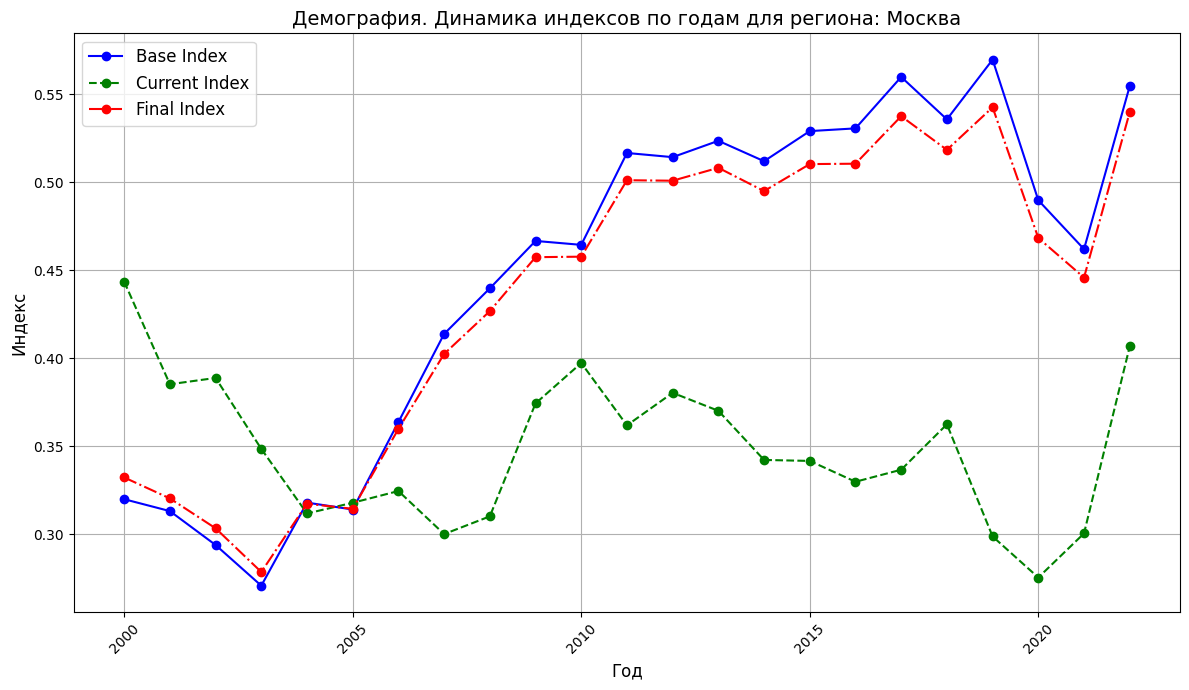

In [1354]:
plot_index_trends_multi(population_indexes_by_base, population_indexes_by_current, population_final, 'Москва', "Демография")

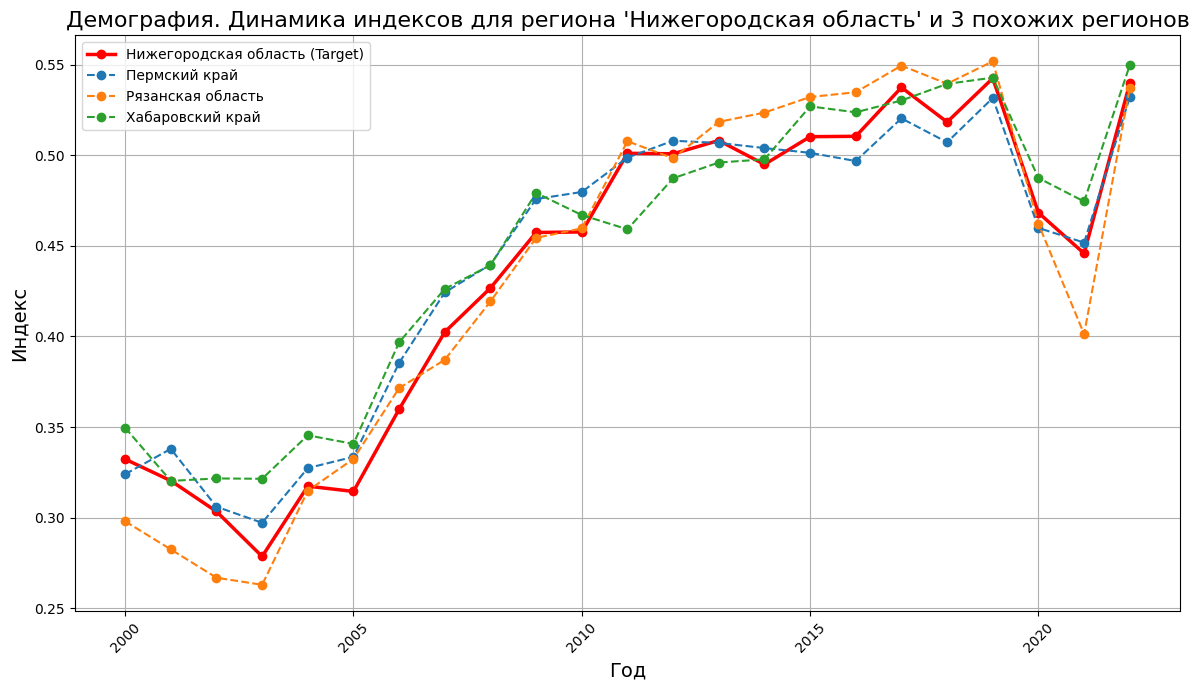

In [1362]:
plot_index_trends_with_similar(
    population_indexes_by_base,
    population_indexes_by_current,
    population_final,
    'Нижегородская область',
    "Демография",
    3
)

In [1364]:
mean_weights = mean_weight(weights_by_base, weights_by_current)
names = population[2000].columns[3:]
weight_report = pd.DataFrame([names, mean_weights], index=['Показатель', 'Вес']).transpose().sort_values(by='Вес', ascending=False).reset_index().drop('index', axis=1)
weight_report # топ k по важности имеет смысл выводить как-то

,Показатель,Вес
0,Ожидаемая продолжительность жизни при рождении...,0.152413
1,Ожидаемая продолжительность жизни при рождении...,0.142943
2,Коэффициенты демографической нагрузки: Всего (...,0.131368
3,Ожидаемая продолжительность жизни при рождении...,0.127905
4,Смертность населения в трудоспособном возрасте...,0.113498
5,Коэффициенты младенческой смертности (число де...,0.102551
6,Общие коэффициенты смертности (число умерших н...,0.075388
7,Соотношение браков и разводов (на 1000 браков ...,0.049668
8,Коэффициенты естественного прироста населения ...,0.049401
9,Суммарный коэффициент рождаемости (число детей...,0.03214


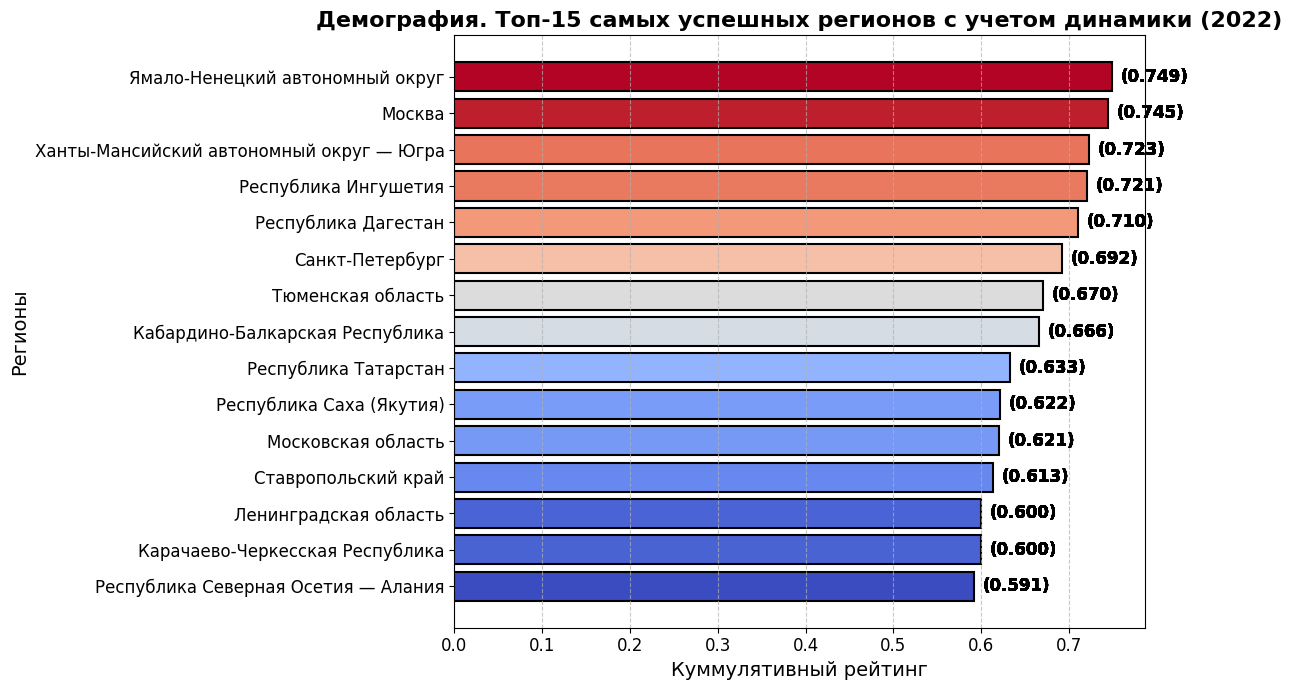

In [1368]:
plot_top_successful_regions_dynamic(population_final, "Демография", 15, 0.1)

### Пайплан

In [22]:
domen = population
domen_name = "Демография"

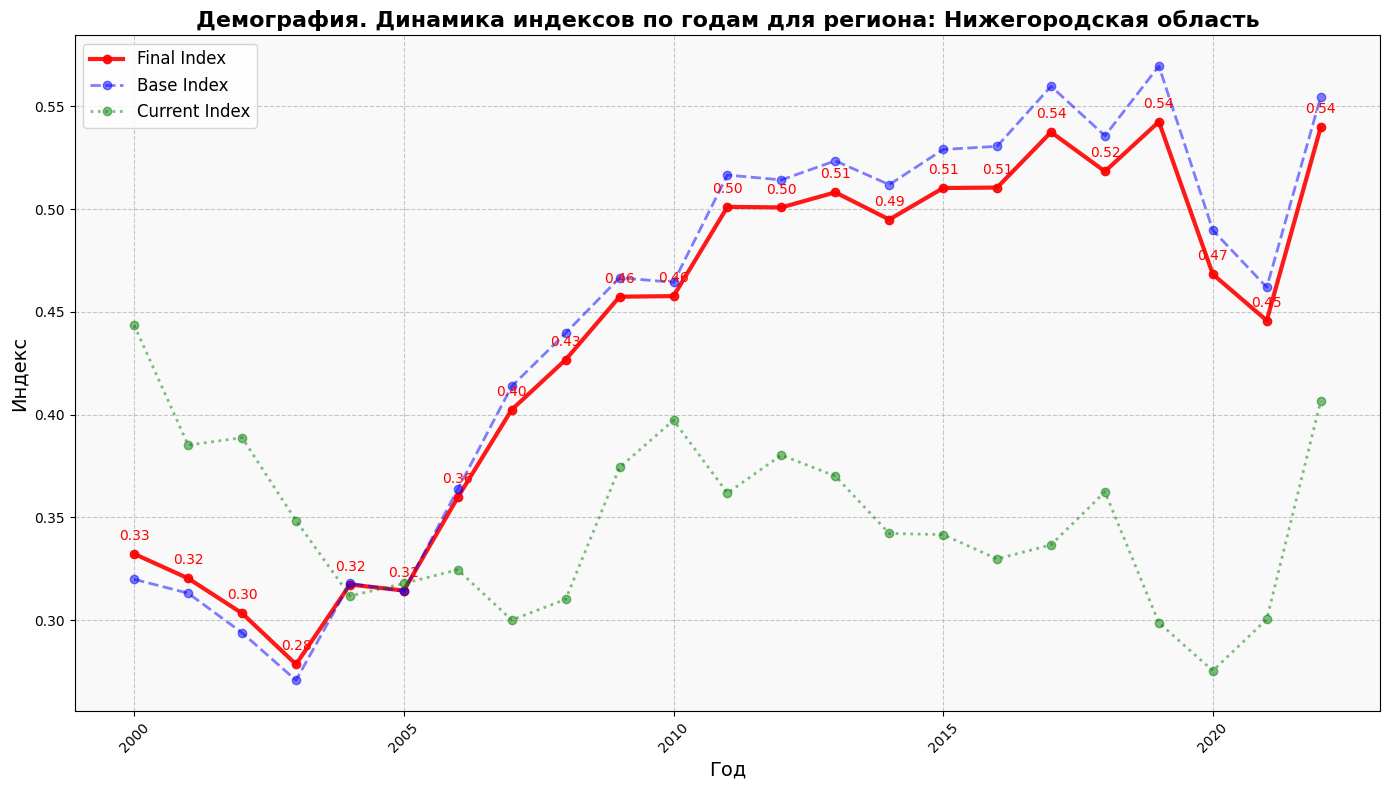

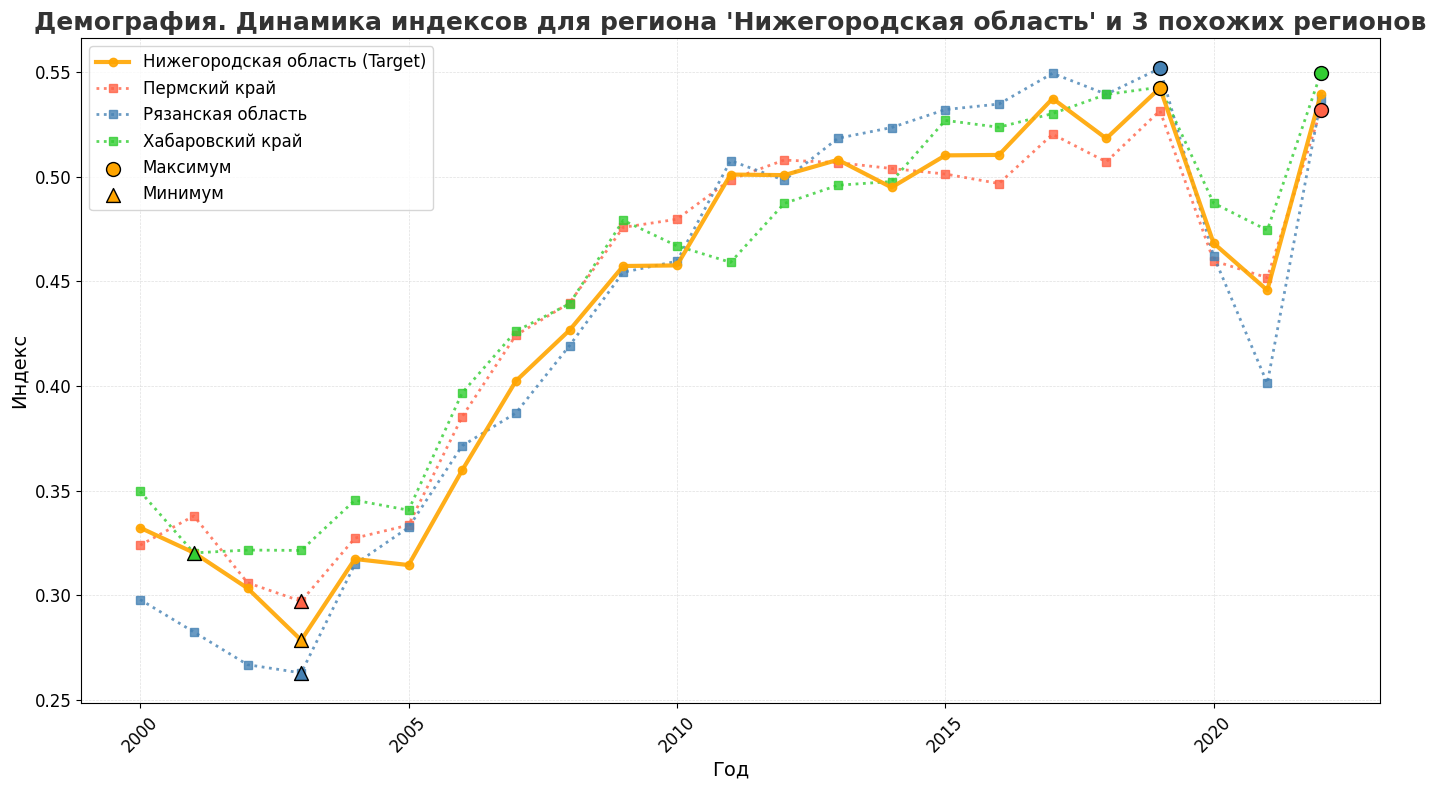

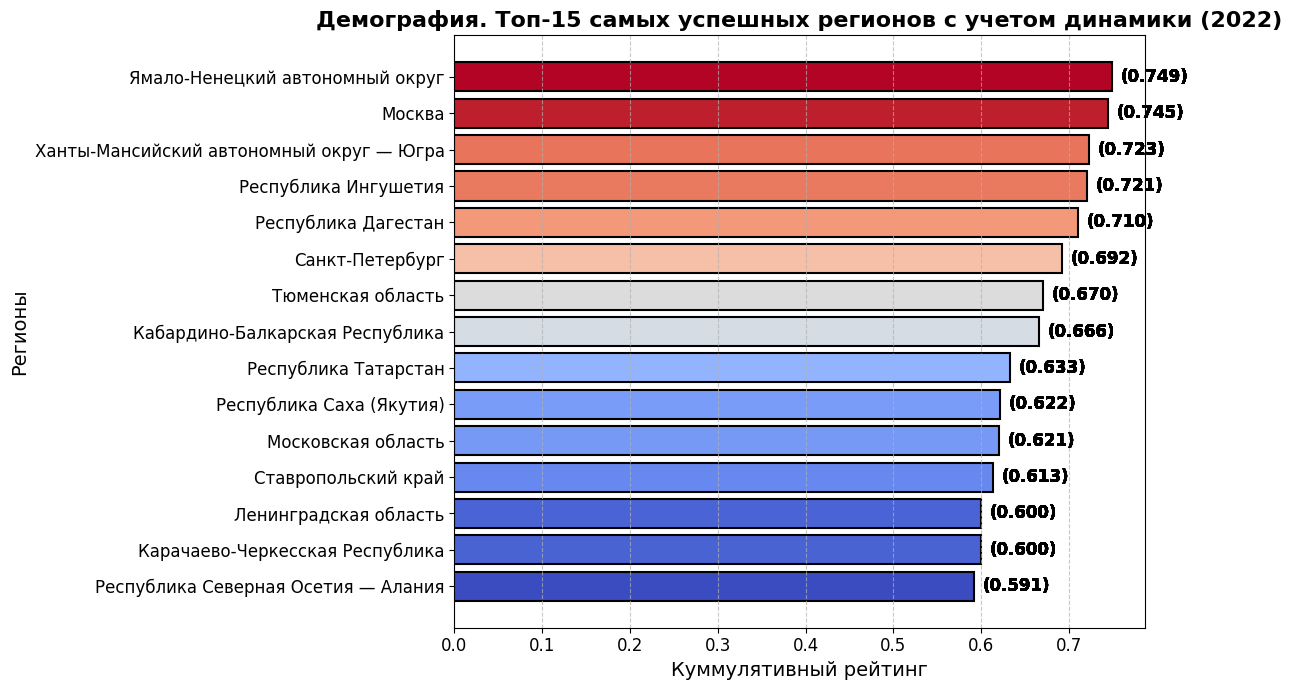

,Показатель,Вес
0,Ожидаемая продолжительность жизни при рождении: Мужчины (число лет),0.152413
1,Ожидаемая продолжительность жизни при рождении: Все население (число лет),0.142943
2,"Коэффициенты демографической нагрузки: Всего (оценка на конец года, на 1000 человек трудоспособного возраста приходится лиц нетрудоспособных возрастов)",0.131368
3,Ожидаемая продолжительность жизни при рождении: Женщины (число лет),0.127905
4,Смертность населения в трудоспособном возрасте (число умерших на 100 000 человек соответствующего возраста),0.113498
5,"Коэффициенты младенческой смертности (число детей, умерших в возрасте до 1 года, на 1000 родившихся живыми)",0.102551
6,Общие коэффициенты смертности (число умерших на 1000 человек населения),0.075388
7,Соотношение браков и разводов (на 1000 браков приходится разводов),0.049668
8,Коэффициенты естественного прироста населения на 1000 человек населения (ND),0.049401
9,Суммарный коэффициент рождаемости (число детей на 1 женщину),0.03214


In [105]:
domen = {year : domen[year][domen[year]['object_level'] == 'регион'] for year in domen.keys()}
for year, df in domen.items():
    domen[year] = drop_missing_values(df, domen[list(domen.keys())[0]].columns)
domen_norm_by_current = normalized_dict_by_minmax(domen)
domen_norm_by_base = normalized_dict_by_minmax_by_base_year(domen, base_year=2010)
domen_indexes_by_base, weights_by_base = calculate_index_with_weights(domen_norm_by_base)
domen_indexes_by_current, weights_by_current = calculate_index_with_weights(domen_norm_by_current)
domen_final = combine_indices(domen_indexes_by_base, domen_indexes_by_current, 0.9) 
plot_index_trends_multi(domen_indexes_by_base, domen_indexes_by_current, domen_final, 'Нижегородская область', domen_name)
plot_index_trends_with_similar(
    domen_indexes_by_base,
    domen_indexes_by_current,
    domen_final,
    'Нижегородская область',
    domen_name,
    3
)
plot_top_successful_regions_dynamic(domen_final, domen_name, 15, 0.1)
mean_weights = mean_weight(weights_by_base, weights_by_current)
names = domen[2000].columns[3:]
weight_report = pd.DataFrame([names, mean_weights], index=['Показатель', 'Вес']).transpose().sort_values(by='Вес', ascending=False).reset_index().drop('index', axis=1)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
weight_report # топ k по важности имеет смысл выводить как-то

In [79]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')

In [1]:
# вес на значение части / весь индекс = доля влияния признака